# Analysis of wavefront sensor data from ALS 5.3.1

Date: Created May 2026 

Author: Wei "Francis" He (francisho@lbl.gov)

Based on earlier versions by Dr. Antoine Islegen-Wojdyla and myself. 

___

## Overview

We (Antoine, Henry, and Francis) collected a new set of data (this time with better metadata, and no binning) with various bender settings and photon energy settings. We want to analyze that data.


# SETUP 

## Import library 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
from scipy.signal import find_peaks

from tiled.client import from_uri
import os
import sys


In [4]:
import monoplus as mp
import wfs_live as wfl


In [5]:
# Load TIFF Image
filename = "wfs_9p2keV_1500um_-4p41mm_rz0p047deg_rx-0p31deg_2inch_mirror_0p185deg_.tiff"
im = Image.open(f'{filename}')
width, height = im.size

print(f"Loaded: {filename}")
print(f"Image dimensions: {width} × {height} pixels")


Loaded: wfs_9p2keV_1500um_-4p41mm_rz0p047deg_rx-0p31deg_2inch_mirror_0p185deg_.tiff
Image dimensions: 5480 × 3648 pixels


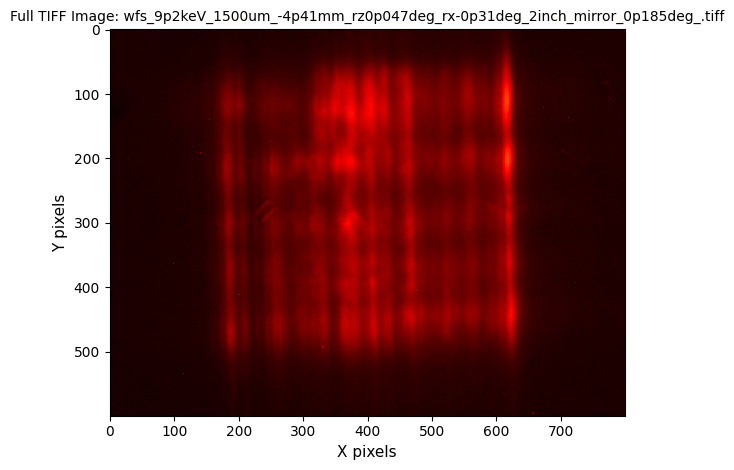

In [13]:
# Visualize full image
# plt.figure(figsize=(8, 5))
plt.imshow(np.array(im).T[3000:3600,800:1600], cmap='hot', interpolation='nearest')
plt.title(f'Full TIFF Image: {filename}', fontsize=10)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
# plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [17]:
# Physical Parameters (Experimental Setup)

z_gd_m = 0.3

camera_pixel_m = 2.4e-6      # Camera pixel size [m]
magnification = 5          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 9200               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 6.2e-6      # Shearing grating pitch [m]

# Data dimensions
Nx = 1000                     # Number of pixels in 1D profile
x_m = np.arange(Nx) * dx_m   # Spatial axis [m]

print(f"Experimental Parameters:")
print(f"{'='*60}")
print(f"Wavelength: {wavelength_m*1e9:.3f} nm ({energy_eV} eV)")
print(f"Effective pixel size: {dx_m*1e6:.3f} μm")
print(f"Grating pitch: {grating_pitch_m*1e6:.1f} μm")
print(f"Spatial extent: {x_m[-1]*1e3:.2f} mm")

Experimental Parameters:
Wavelength: 0.135 nm (9200 eV)
Effective pixel size: 0.480 μm
Grating pitch: 6.2 μm
Spatial extent: 0.48 mm


/home/bl531/python/nabla/wfs-als531/wfs_live.py:1032: UserWarning: k_peak=111.1 cyc/mm landed within 5% of k_ideal of a search-band edge [107.5, 241.9] cyc/mm. Consider increasing band_factor (currently 1.5).
  car = find_carrier(profile, dx, grating_pitch, band_factor=band_factor)


[ bad]  λ=0.13nm  k_peak=111.1 cyc/mm  r_DC=308.8  SNR=3.0  f_pred=-0.95m  RMS_W=3.6nm  RMS_resid=0.087nm


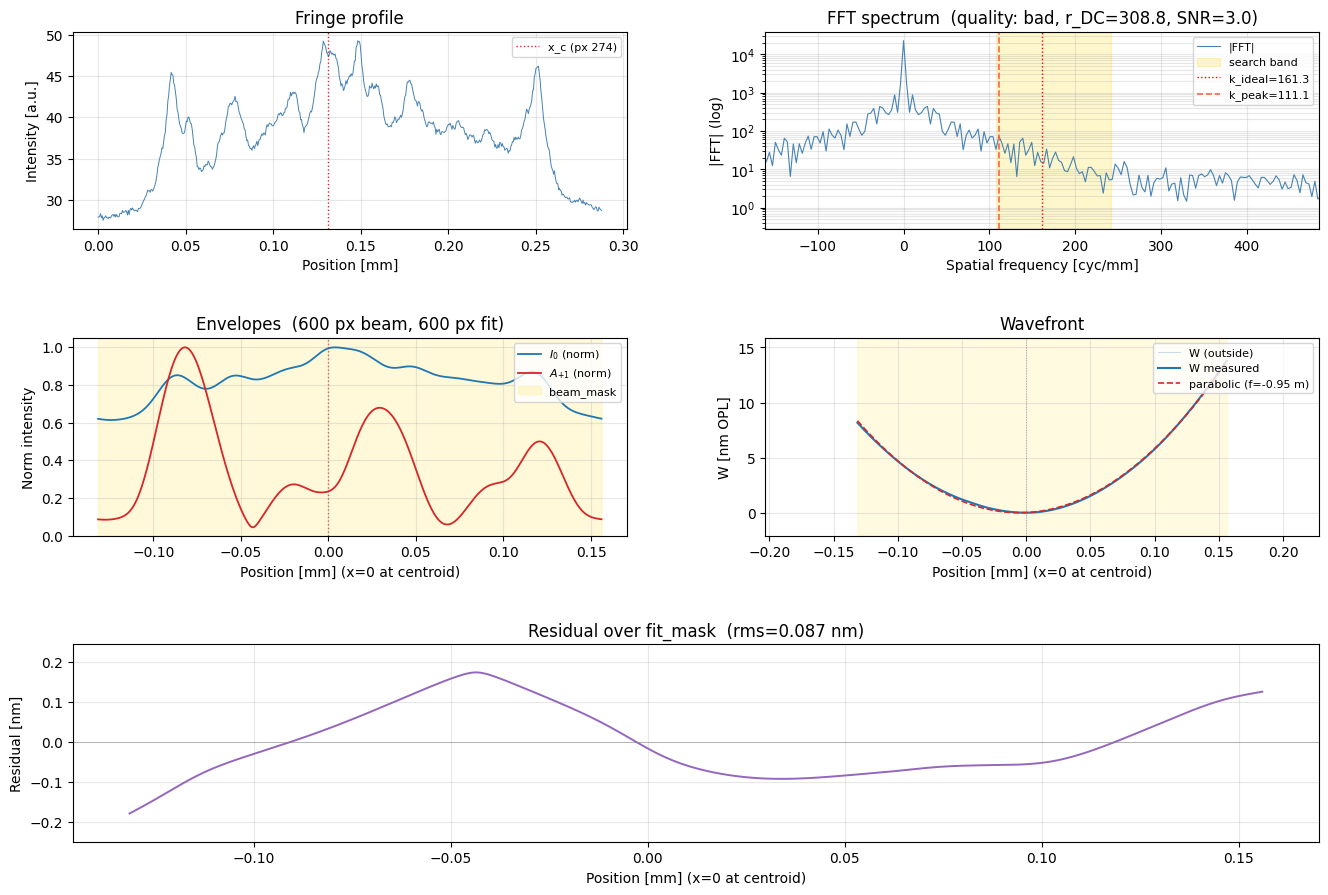

In [19]:
y_roi = slice(3500, 3520)

r_quick_bare = wfl.quick_look(
    np.array(im)[900:1500], dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=1, propagate=False, V_threshold=0
)